### Table of Contents

1. [Introduction](#1.-introduction)

2. [Data](#2.-data)

3. [Methodology](#3.-methodology)

4. [Data Pre-processing](#4.-data-pre-processing)

    4.1. [Raw Dataset Loading & Inspection](#4.1.-raw-dataset-loading--inspection)

    4.2. [Conversion of WDI Dataset to Wide-format Panel Data](#4.2.-conversion-of-wdi-dataset-to-wide-format-panel-data)

    4.3. [Panel Balance Check](#4.3.-panel-balance-check)

    4.4. [Data Integrity Checks & Cleanup](#4.4.-data-integrity-checks--cleanup)

5. [Variable Transformations and Panel Data Prep](#5.-variable-transformations-and-panel-data-prep)

    5.1. [Variable Transformations](#5.1.-variable-transformations)

    5.2 [Missing Value Handling](#5.2.-missing-value-handling)

    5.3 [Sorting and Indexing Panel Data](#5.3.-sorting-and-indexing-panel-data)

    5.4 [Multicollinearity Check (VIF)](#5.4.-multicollinearity-check-vif)

6. [Econometric Modeling](#6.-econometric-modeling)

    6.1 [Pooled OLS (Baseline Reference Model)](#6.1.-pooled-ols-baseline-reference-model)

    6.2 [Entity Fixed Effects (FE) Model](#6.2.-entity-fixed-effects-fe-model)

    6.3 [Random Effects (RE) Model](#6.3.-random-effects-re-model)

    6.4 [Hausman Test (FE vs RE)](#6.4.-hausman-test-fe-vs-re)

    6.5 [Two-Way Fixed Effects (Entity + Year FE)](#6.5.-two-way-fixed-effects-entity--year-fe)

    6.6 [Coefficients and their Statistical Significance](#6.6.-coefficients-and-their-statistical-significance)

7. [Results and Interpretation](#7.-results-and-interpretation)

    7.1. [EKC Turning Point Analysis](#7.1.-ekc-turning-point-analysis)

    7.2 [EKC Curve Visualization (Predicted $lnCO_2$ vs lnGDP)](#7.2.-ekc-curve-visualization-(predicted-lnco_2-vs-lngdp))

    7.3 [Year Fixed Effects Plot](#7.3.-year-fixed-effects-plot)

    7.4 [Coefficient Plot (Two-Way FE Model)](#7.4.-coefficient-plot-(two-way-fe-model))

    7.5 [Actual vs Fitted Plot (Two-Way FE Model)](#7.5.-actual-vs-fitted-plot-(two-way-fe-model))

    7.6 [Time Fixed Effects Plot](#7.6.-time-fixed-effects-plot)

    7.7 [First-order Autocorrelation in Idiosyncratic Errors](#7.7.-first-order-autocorrelation-in-idiosyncratic-errors)

### 1. Introduction

**Research Question**  
Do countries’ economic growth and structural change explain variation in carbon dioxide emissions per capita? Does an increase in GDP per capita result in higher level of emissions?

**Motivation**    
While rapid industrial expansion and urbanization have boosted the global economy, they have introduced significant sustainability risks. Furthermore, as emerging factors like Digital and AI waste pose unprecedented risks, finding the balance between growth and sustainability is central to today’s economic policy debate. The subject of this research links macroeconomic performance and environmental outcomes while associating structural shifts for explainability.

**Background and Existing Findings**  
Simon Kuznets researched the relationship between a nation’s growth and its environmental effect, popularly known as the Environmental Kuznets Curve (EKC). Numerous studies in Environmental Economics have established an inverted-U relationship between GDP and emissions. However, results can vary depending on the class of pollutants, time periods, and country groups. Recent studies suggest that structural variables and energy composition may alter the growth-emission relationship, hence the scope for an updated assessment.

### 2. Data

We are using a balanced panel from the World Bank’s World Development Indicators database for all available countries between 2000 and 2022. The dataset will combine measures of CO₂ emissions, GDP per capita, trade, industrial value added (as a percentage of GDP), energy use, shares of renewable and fossil-fuel energy, urban population, and population density.

[World Bank World Development Indicators (WDI) Panel Data 2000-2022](https://github.com/priyadarshanparida/kuznets-hypothesis-growth-vs-sustainability-buan6312/blob/main/data/panel_raw_wdi_2000_2022.csv)

### 3. Methodology

We hypothesize CO₂ emissions per capita to initially rise with income and later decline as economies diversify and adopt cleaner energy sources – a pattern consistent with the Environmental Kuznets Curve. The economic research will estimate a linear model including income and emissions to capture the EKC shape with the coefficient on GDP being our parameter of interest. Panel fixed-effects estimation will be used to control for unobserved, time-invariant country characteristics.

### 4. Data Pre-processing

In [103]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm
from linearmodels import PooledOLS
from linearmodels import PanelOLS
from linearmodels import RandomEffects
from linearmodels.panel import compare
from statsmodels.stats.outliers_influence import variance_inflation_factor

##### 4.1 Raw Dataset Loading & Inspection

In [104]:
# Load dataset
filepath = "../data/panel_raw_wdi_2000_2022.csv"
wdi_panel_raw = pd.read_csv(filepath)

# Basic structure checks
print(f"Dataset Shape: {wdi_panel_raw.shape}    ")
print(f"Columns: {wdi_panel_raw.columns.tolist()}")
print(f"Sample Observations: {wdi_panel_raw.head()}")

Dataset Shape: (2394, 27)    
Columns: ['Country Name', 'Country Code', 'Series Name', 'Series Code', '2000 [YR2000]', '2001 [YR2001]', '2002 [YR2002]', '2003 [YR2003]', '2004 [YR2004]', '2005 [YR2005]', '2006 [YR2006]', '2007 [YR2007]', '2008 [YR2008]', '2009 [YR2009]', '2010 [YR2010]', '2011 [YR2011]', '2012 [YR2012]', '2013 [YR2013]', '2014 [YR2014]', '2015 [YR2015]', '2016 [YR2016]', '2017 [YR2017]', '2018 [YR2018]', '2019 [YR2019]', '2020 [YR2020]', '2021 [YR2021]', '2022 [YR2022]']
Sample Observations:   Country Name Country Code  \
0  Afghanistan          AFG   
1  Afghanistan          AFG   
2  Afghanistan          AFG   
3  Afghanistan          AFG   
4  Afghanistan          AFG   

                                         Series Name           Series Code  \
0  Carbon dioxide (CO2) emissions excluding LULUC...  EN.GHG.CO2.PC.CE.AR5   
1                 GDP per capita (constant 2015 US$)        NY.GDP.PCAP.KD   
2       Energy use (kg of oil equivalent per capita)     EG.USE.P

##### 4.2 Conversion of WDI Dataset to Wide-format Panel Data

In [105]:
# 4.2.1 Melt the year columns (2000–2022) into a single Year column
wdi_panel_long = wdi_panel_raw.melt(
    id_vars=["Country Name", "Country Code", "Series Name", "Series Code"],
    var_name="Year",
    value_name="Value"
)

# Clean up the Year column to retain only the numeric year (e.g., "2000" from "2000 [YR2000]")
wdi_panel_long["Year"] = wdi_panel_long["Year"].str.extract(r"(\d{4})").astype(int)

# Convert Value to numeric
wdi_panel_long["Value"] = pd.to_numeric(wdi_panel_long["Value"], errors="coerce")

# Quick check of the structure
print("Shape after melting:", wdi_panel_long.shape)
print(f"Missingness Summary: {wdi_panel_long.isna().sum()}")

Shape after melting: (55062, 6)
Missingness Summary: Country Name       0
Country Code       0
Series Name        0
Series Code        0
Year               0
Value           5982
dtype: int64


In [106]:
# 4.2.2 Pivot indicators so each variable becomes its own column

# Pivot: each Series Code becomes a separate column
wdi_panel = wdi_panel_long.pivot_table(
    index=["Country Name", "Country Code", "Year"],
    columns="Series Code",
    values="Value"
).reset_index()

# Drop the pivot_table column index name
wdi_panel.columns.name = None

# Rename key indicators for clarity
rename_map = {
    "Country Name": "country_name",
    "Country Code": "country_code",
    "Year": "year",
    "EN.GHG.CO2.PC.CE.AR5": "co2_per_capita",
    "NY.GDP.PCAP.KD": "gdp_per_capita",
    "EG.USE.PCAP.KG.OE": "energy_use_per_capita",
    "SP.URB.TOTL.IN.ZS": "urban_pct",
    "NE.TRD.GNFS.ZS": "trade_pct_gdp",
    "EG.FEC.RNEW.ZS": "renewable_pct",
    "NV.IND.TOTL.ZS": "industry_value_added_pct_gdp",
    "EG.USE.COMM.FO.ZS": "fossil_fuel_pct",
    "EN.POP.DNST": "population_density"
}
wdi_panel.rename(columns=rename_map, inplace=True)

# Sort for clean panel structure
wdi_panel = wdi_panel.sort_values(["country_name", "year"]).reset_index(drop=True)

# Quick check
print("Shape after pivot:", wdi_panel.shape)
print(wdi_panel.head())

# Missingness summary after pivot
print("\nMissingness Summary (post-pivot):")
print(wdi_panel.isna().sum())

Shape after pivot: (6084, 12)
  country_name country_code  year  renewable_pct  fossil_fuel_pct  \
0  Afghanistan          AFG  2000        45.0000              NaN   
1  Afghanistan          AFG  2001        45.6000              NaN   
2  Afghanistan          AFG  2002        37.8000              NaN   
3  Afghanistan          AFG  2003        36.7000              NaN   
4  Afghanistan          AFG  2004        44.2000              NaN   

   energy_use_per_capita  co2_per_capita  population_density  trade_pct_gdp  \
0                    NaN          0.0505             30.8638            NaN   
1                    NaN          0.0466             31.0999            NaN   
2                    NaN          0.0441             32.7770            NaN   
3                    NaN          0.0443             34.8543            NaN   
4                    NaN          0.0379             36.1232            NaN   

   industry_value_added_pct_gdp  gdp_per_capita  urban_pct  
0                  

##### 4.3 Panel Balance Check

In [107]:
def check_panel_balance(df, country_col="country_name", year_col="year", n_sample=5):
    """
    Prints panel balance diagnostics for any country–year panel DataFrame.
    """
    # Basic counts
    print(f"Unique Countries: {df[country_col].nunique()}")
    print(f"Unique Years: {df[year_col].nunique()}")
    print(f"Year Range: {df[year_col].min()} — {df[year_col].max()}")

    # Expected vs actual
    expected_obs = df[country_col].nunique() * df[year_col].nunique()
    print(f"Expected Observations (if balanced): {expected_obs}")
    print(f"Actual Observations: {df.shape[0]}")

    # Observations per country
    country_year_counts = (
        df.groupby(country_col)[year_col]
        .nunique()
        .sort_values()
    )
    print("\nCountries with the fewest years of data:")
    print(country_year_counts.head(10))

    print("\nCountries with the most years of data:")
    print(country_year_counts.tail(10))

    # Missing years per country
    all_years = set(df[year_col].unique())
    missing_years = {
        c: sorted(all_years - set(yrs))
        for c, yrs in df.groupby(country_col)[year_col].unique().items()
    }

    print(f"\nSample Missing Years for First {n_sample} Countries:")
    for c in list(missing_years.keys())[:n_sample]:
        print(c, ":", missing_years[c])


In [108]:
# 4.3 Panel Balance Check
check_panel_balance(wdi_panel)

Unique Countries: 265
Unique Years: 23
Year Range: 2000 — 2022
Expected Observations (if balanced): 6095
Actual Observations: 6084

Countries with the fewest years of data:
country_name
St. Martin (French part)    12
Afghanistan                 23
Mozambique                  23
Myanmar                     23
Namibia                     23
Nauru                       23
Nepal                       23
Netherlands                 23
New Caledonia               23
New Zealand                 23
Name: year, dtype: int64

Countries with the most years of data:
country_name
Ghana                                       23
Gibraltar                                   23
Greece                                      23
Greenland                                   23
Grenada                                     23
Guam                                        23
Guatemala                                   23
Guinea                                      23
Fragile and conflict affected situations    23
Zim

##### 4.4 Data Integrity Checks & Cleanup

In [109]:
# 4.4.1 Check for duplicate rows
duplicates = wdi_panel.duplicated(subset=["country_name", "year"], keep=False)
print(f"Number of duplicate country-year rows: {duplicates.sum()}")

# 4.4.2 Confirm uniqueness of country-year keys
unique_pairs = wdi_panel[["country_name", "year"]].drop_duplicates().shape[0]
print(f"Unique country-year pairs: {unique_pairs}")
print(f"Total rows: {wdi_panel.shape[0]}")

# 4.4.3 Negative values check
numeric_cols = [
    "co2_per_capita",
    "gdp_per_capita",
    "energy_use_per_capita",
    "population_density",
    "renewable_pct",
    "fossil_fuel_pct",
    "industry_value_added_pct_gdp",
    "trade_pct_gdp",
    "urban_pct"
]

negative_counts = (wdi_panel[numeric_cols] < 0).sum()
print("\nNegative values detected:")
print(negative_counts)

# 4.4.4 Check for unrealistic percentage values (>100)
pct_cols = [
    "renewable_pct",
    "fossil_fuel_pct",
    "industry_value_added_pct_gdp",
    "trade_pct_gdp",
    "urban_pct"
]

over_100_counts = (wdi_panel[pct_cols] > 100).sum()
print("\nPercentage columns with values > 100:")
print(over_100_counts)

# 4.4.5 Missingness summary (post-cleaning)
print(f"\nMissingness Summary (final pre-processing):\n{wdi_panel.isna().sum()}")
print(f"\nTotal missing cells: {wdi_panel.isna().sum().sum()}")

# Reorder columns for better readability
ordered_cols = [
    "country_name",
    "country_code",
    "year",
    "co2_per_capita",
    "gdp_per_capita",
    "energy_use_per_capita",
    "urban_pct",
    "trade_pct_gdp",
    "renewable_pct",
    "fossil_fuel_pct",
    "industry_value_added_pct_gdp",
    "population_density"
]

wdi_panel = wdi_panel[ordered_cols]
wdi_panel.columns

Number of duplicate country-year rows: 0
Unique country-year pairs: 6084
Total rows: 6084

Negative values detected:
co2_per_capita                  0
gdp_per_capita                  0
energy_use_per_capita           0
population_density              0
renewable_pct                   0
fossil_fuel_pct                 6
industry_value_added_pct_gdp    0
trade_pct_gdp                   0
urban_pct                       0
dtype: int64

Percentage columns with values > 100:
renewable_pct                      0
fossil_fuel_pct                    0
industry_value_added_pct_gdp       0
trade_pct_gdp                   1343
urban_pct                          0
dtype: int64

Missingness Summary (final pre-processing):
country_name                       0
country_code                       0
year                               0
renewable_pct                    374
fossil_fuel_pct                 1592
energy_use_per_capita           1519
co2_per_capita                   311
population_density     

Index(['country_name', 'country_code', 'year', 'co2_per_capita',
       'gdp_per_capita', 'energy_use_per_capita', 'urban_pct', 'trade_pct_gdp',
       'renewable_pct', 'fossil_fuel_pct', 'industry_value_added_pct_gdp',
       'population_density'],
      dtype='object')

In [110]:
# 4.4.6: Keep only codes that are true ISO-3 country codes recognized by WDI
print("Shape before filtering countries:", wdi_panel.shape)
print(f"Unique countries in the WDI dataset before filtering to valid ISO-3 codes: {wdi_panel['country_name'].nunique()}")
wdi_countries = wdi_panel[wdi_panel["country_code"].isin(
    pd.read_csv("../data/country-codes.csv")["ISO3166-1-Alpha-3"].dropna().unique()
)]
print("Shape after filtering countries:", wdi_countries.shape)
print(f"Unique countries in the WDI dataset after filtering to valid ISO-3 codes: {wdi_countries['country_name'].nunique()}")
# Countries dropped
print("Countries dropped during filtering:", set(wdi_panel["country_name"]) - set(wdi_countries["country_name"]))

Shape before filtering countries: (6084, 12)
Unique countries in the WDI dataset before filtering to valid ISO-3 codes: 265
Shape after filtering countries: (4934, 12)
Unique countries in the WDI dataset after filtering to valid ISO-3 codes: 215
Countries dropped during filtering: {'Sub-Saharan Africa', 'Latin America & Caribbean (excluding high income)', 'Least developed countries: UN classification', 'Central Europe and the Baltics', 'Low income', 'Latin America & the Caribbean (IDA & IBRD countries)', 'Europe & Central Asia (excluding high income)', 'European Union', 'Pacific island small states', 'IBRD only', 'Sub-Saharan Africa (excluding high income)', 'East Asia & Pacific', 'East Asia & Pacific (excluding high income)', 'Other small states', 'World', 'Kosovo', 'IDA & IBRD total', 'Middle East, North Africa, Afghanistan & Pakistan (excluding high income)', 'Euro area', 'IDA only', 'East Asia & Pacific (IDA & IBRD countries)', 'Channel Islands', 'Sub-Saharan Africa (IDA & IBRD cou

### 5. Variable Transformations and Panel Data Prep

##### 5.1 Variable Transformations

In [111]:
# 5.1.1 Log-transform positive continuous variables
log_vars = {
    "co2_per_capita": "lnCO2",
    "gdp_per_capita": "lnGDP",
    "energy_use_per_capita": "lnEnergy",
    "urban_pct": "lnUrban",
    "trade_pct_gdp": "lnTrade",
    "population_density": "lnPopDensity"
}

panel_df = wdi_countries.copy()

# Convert invalid values to NaN before logging
for src, tgt in log_vars.items():
    panel_df[tgt] = panel_df[src].apply(
        lambda x: np.log(x) if pd.notna(x) and x > 0 else np.nan
    )

# 5.1.2 Add GDP squared term
panel_df["lnGDP_sq"] = panel_df["lnGDP"] ** 2

# 5.1.3 Keep level variables as-is
level_vars = ["renewable_pct", "fossil_fuel_pct", "industry_value_added_pct_gdp"]

print(f"Panel data columns: {panel_df.columns}")

Panel data columns: Index(['country_name', 'country_code', 'year', 'co2_per_capita',
       'gdp_per_capita', 'energy_use_per_capita', 'urban_pct', 'trade_pct_gdp',
       'renewable_pct', 'fossil_fuel_pct', 'industry_value_added_pct_gdp',
       'population_density', 'lnCO2', 'lnGDP', 'lnEnergy', 'lnUrban',
       'lnTrade', 'lnPopDensity', 'lnGDP_sq'],
      dtype='object')


##### 5.2 Missing Value Handling

In [112]:
# Drop rows missing any core variables
print(f"Initial dataset shape: {panel_df.shape}")
print(f"Unique countries: {panel_df['country_name'].nunique()}")
print(f"Years covered: {panel_df['year'].min()} to {panel_df['year'].max()}")

core_vars = list(log_vars.values()) + ["lnGDP_sq"] + level_vars
panel_df = panel_df.dropna(subset=core_vars)

print(f"Final dataset shape: {panel_df.shape}")
print(f"Unique countries: {panel_df['country_name'].nunique()}")
print(f"Years covered: {panel_df['year'].min()} to {panel_df['year'].max()}")

# Panel Balance Check
print("\n*******************************************\n")
check_panel_balance(panel_df)

Initial dataset shape: (4934, 19)
Unique countries: 215
Years covered: 2000 to 2022
Final dataset shape: (2906, 19)
Unique countries: 157
Years covered: 2000 to 2022

*******************************************

Unique Countries: 157
Unique Years: 23
Year Range: 2000 — 2022
Expected Observations (if balanced): 3611
Actual Observations: 2906

Countries with the fewest years of data:
country_name
Lesotho             1
Marshall Islands    1
Guyana              2
Guinea-Bissau       4
Comoros             4
Seychelles          4
Samoa               4
Timor-Leste         4
Cabo Verde          4
Fiji                4
Name: year, dtype: int64

Countries with the most years of data:
country_name
Germany         22
Greece          22
Guatemala       22
Haiti           22
Ghana           22
Kenya           22
Uganda          23
Chad            23
Rwanda          23
Burkina Faso    23
Name: year, dtype: int64

Sample Missing Years for First 5 Countries:
Albania : [np.int64(2022)]
Algeria : [np.int

##### 5.3 Sorting and Indexing Panel Data

In [113]:
panel_df = panel_df.sort_values(["country_name", "year"])
panel_df = panel_df.set_index(["country_name", "year"])
print(f"Panel data is unique: {panel_df.index.is_unique}")

Panel data is unique: True


##### 5.4 Multicollinearity Check (VIF)

In [114]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Use the same regressors as the model input (no year dummies)
X_vif = panel_df[[
    "lnGDP", "lnGDP_sq", "lnEnergy", "lnUrban", "lnTrade",
    "renewable_pct", "fossil_fuel_pct", "lnPopDensity",
    "industry_value_added_pct_gdp"
]].copy()

# Drop any remaining NA (should be none at this point)
X_vif = X_vif.dropna()

# VIF expects a plain numpy array (no index effects)
X_vals = X_vif.values

vif_results = pd.DataFrame({
    "Variable": X_vif.columns,
    "VIF": [variance_inflation_factor(X_vals, i) for i in range(X_vals.shape[1])]
})

vif_results

,Variable,VIF
0,lnGDP,1423.8382
1,lnGDP_sq,277.7752
2,lnEnergy,240.6205
3,lnUrban,267.9245
4,lnTrade,81.5495
5,renewable_pct,4.2230
6,fossil_fuel_pct,3.0551
7,lnPopDensity,12.0300
8,industry_value_added_pct_gdp,8.7153


### 6. Econometric Modeling

##### 6.1 Pooled OLS (Baseline Reference Model)

In [115]:
# 6.1.1 Prepare X and y
y = panel_df["lnCO2"]
X = panel_df[["lnGDP", "lnGDP_sq", "lnEnergy", "lnUrban", "lnTrade",
              "renewable_pct", "fossil_fuel_pct", "lnPopDensity", "industry_value_added_pct_gdp"]]

X = sm.add_constant(X)

# 6.1.2 Fit pooled OLS
pooled_ols = PooledOLS(y, X).fit()

print(pooled_ols.summary)

                          PooledOLS Estimation Summary                          
Dep. Variable:                  lnCO2   R-squared:                        0.9463
Estimator:                  PooledOLS   R-squared (Between):              0.8148
No. Observations:                2906   R-squared (Within):               0.7525
Date:                Fri, Dec 05 2025   R-squared (Overall):              0.9463
Time:                        10:59:52   Log-likelihood                   -988.75
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      5674.5
Entities:                         157   P-value                           0.0000
Avg Obs:                       18.510   Distribution:                  F(9,2896)
Min Obs:                       1.0000                                           
Max Obs:                       23.000   F-statistic (robust):             5674.5
                            

##### 6.2 Entity Fixed Effects (FE) Model

In [116]:
# 6.2.1 Prepare X and y
y = panel_df["lnCO2"]

X = panel_df[[
    "lnGDP", "lnGDP_sq", "lnEnergy", "lnUrban", "lnTrade",
    "renewable_pct", "fossil_fuel_pct", "lnPopDensity",
    "industry_value_added_pct_gdp"
]]

# The constant is excluded because entity fixed effects absorb the intercept in the PanelOLS model
# X = sm.add_constant(X)

# 6.2.2 Fit Entity FE model (cluster by country)
fe_entity = PanelOLS(
    y, 
    X,
    entity_effects=True
).fit(cov_type="clustered", cluster_entity=True)

print(fe_entity.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:                  lnCO2   R-squared:                        0.7674
Estimator:                   PanelOLS   R-squared (Between):             -38.361
No. Observations:                2906   R-squared (Within):               0.7674
Date:                Fri, Dec 05 2025   R-squared (Overall):             -39.604
Time:                        10:59:52   Log-likelihood                    2507.2
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      1004.2
Entities:                         157   P-value                           0.0000
Avg Obs:                       18.510   Distribution:                  F(9,2740)
Min Obs:                       1.0000                                           
Max Obs:                       23.000   F-statistic (robust):             85.145
                            

##### 6.3 Random Effects (RE) Model

In [117]:
# 6.3.1 Prepare X and y (same as FE)
y = panel_df["lnCO2"]

X = panel_df[[
    "lnGDP", "lnGDP_sq", "lnEnergy", "lnUrban", "lnTrade",
    "renewable_pct", "fossil_fuel_pct", "lnPopDensity",
    "industry_value_added_pct_gdp"
]]

# 6.3.2 Fit RE model
re_model = RandomEffects(y, X).fit()

print(re_model.summary)

                        RandomEffects Estimation Summary                        
Dep. Variable:                  lnCO2   R-squared:                        0.7138
Estimator:              RandomEffects   R-squared (Between):              0.8120
No. Observations:                2906   R-squared (Within):               0.7049
Date:                Fri, Dec 05 2025   R-squared (Overall):              0.9178
Time:                        10:59:52   Log-likelihood                    2082.7
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      802.87
Entities:                         157   P-value                           0.0000
Avg Obs:                       18.510   Distribution:                  F(9,2897)
Min Obs:                       1.0000                                           
Max Obs:                       23.000   F-statistic (robust):             802.87
                            

##### 6.4 Hausman Test (FE vs RE)

In [118]:
# Extract coefficients
b_fe = fe_entity.params
b_re = re_model.params

# Extract covariance matrices
v_fe = fe_entity.cov
v_re = re_model.cov

# Identify common coefficients
common_coef = list(set(b_fe.index) & set(b_re.index))

# Compute differences
b_diff = b_fe[common_coef] - b_re[common_coef]
v_diff = v_fe.loc[common_coef, common_coef] - v_re.loc[common_coef, common_coef]

# Hausman statistic
hausman_stat = float(b_diff.T @ np.linalg.inv(v_diff) @ b_diff)
df = len(common_coef)
p_value = 1 - stats.chi2.cdf(hausman_stat, df)

print("\nHausman test statistic:", round(hausman_stat, 3))
print("Degrees of freedom:", df)
print("p-value:", round(p_value, 5))

if p_value < 0.05:
    print("Reject H0: Random Effects inconsistent → use Fixed Effects.")
else:
    print("Fail to reject H0: Random Effects acceptable.")



Hausman test statistic: 72.952
Degrees of freedom: 9
p-value: 0.0
Reject H0: Random Effects inconsistent → use Fixed Effects.


##### 6.5 Two-Way Fixed Effects (Entity + Year FE)

In [119]:
# Two-Way FE with Manual Time Dummies

# Ensure sorted panel index (important)
panel_df = panel_df.sort_index()

# 6.5.1 Create year dummies
years = panel_df.index.get_level_values("year")
time_dummies = pd.get_dummies(years, drop_first=True)

# Align index
time_dummies.index = panel_df.index
time_dummies.columns = [f'd{year}' for year in sorted(years.unique())[1:]]

# 6.5.2 Combine regressors + time dummies
X_tw = pd.concat([X, time_dummies], axis=1)

# 6.5.3 Fit Two-Way FE (Entity FE + manual year dummies)
fe_tw_manual = PanelOLS(
    y,
    X_tw,
    entity_effects=True
).fit(cov_type="clustered", cluster_entity=True)

print(fe_tw_manual.summary)


                          PanelOLS Estimation Summary                           
Dep. Variable:                  lnCO2   R-squared:                        0.7756
Estimator:                   PanelOLS   R-squared (Between):             -38.032
No. Observations:                2906   R-squared (Within):               0.7756
Date:                Fri, Dec 05 2025   R-squared (Overall):             -39.335
Time:                        10:59:52   Log-likelihood                    2559.8
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      303.09
Entities:                         157   P-value                           0.0000
Avg Obs:                       18.510   Distribution:                 F(31,2718)
Min Obs:                       1.0000                                           
Max Obs:                       23.000   F-statistic (robust):             54.100
                            

##### 6.6 Coefficients and their Statistical Significance

In [120]:
def significance_stars(p):
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    elif p < 0.10:
        return "."
    else:
        return ""
        

def color_pvals(val):
    """Color code based on p-value significance."""
    if val < 0.001:
        return "font-weight: bold; color: green;"       # highly significant
    elif val < 0.01:
        return "color: green;"                          # significant
    elif val < 0.05:
        return "color: darkgreen;"                      # weak significance
    elif val < 0.10:
        return "color: orange;"                         # marginal
    else:
        return "color: red;"                            # not significant

def make_coef_table(model_results):
    """Return a clean coefficient table from linearmodels results."""

    params = model_results.params
    se     = model_results.std_errors
    tvals  = model_results.tstats
    pvals  = model_results.pvalues
    conf   = model_results.conf_int()

    table = pd.DataFrame({
        "Estimate": params,
        "Std.Error": se,
        "t-value": tvals,
        "p-value": pvals,
        "Signif": pvals.apply(significance_stars),
        "CI 2.5%": conf.iloc[:, 0],
        "CI 97.5%": conf.iloc[:, 1]
    })

    # Display formatting
    pd.set_option("display.float_format", lambda x: f"{x:0.4f}")
    
    # Styled output
    styled = table.style.map(color_pvals, subset=["p-value"])
    return styled, table

styled_table, raw_table = make_coef_table(fe_tw_manual)
styled_table

,Estimate,Std.Error,t-value,p-value,Signif,CI 2.5%,CI 97.5%
lnGDP,1.275028,0.307600,4.145080,0.000035,***,0.671874,1.878181
lnGDP_sq,-0.058690,0.017412,-3.370722,0.000760,***,-0.092831,-0.024548
lnEnergy,0.618930,0.081794,7.566901,0.000000,***,0.458544,0.779315
lnUrban,0.248849,0.182530,1.363334,0.172890,,-0.109062,0.606760
lnTrade,0.040493,0.038284,1.057710,0.290282,,-0.034575,0.115562
renewable_pct,-0.016970,0.002214,-7.666056,0.000000,***,-0.021310,-0.012629
fossil_fuel_pct,0.001359,0.000551,2.466510,0.013705,*,0.000279,0.002439
lnPopDensity,-0.001270,0.127739,-0.009942,0.992068,,-0.251745,0.249205
industry_value_added_pct_gdp,0.001715,0.002037,0.841676,0.400043,,-0.002280,0.005709
d2001,-0.009203,0.003766,-2.443685,0.014601,*,-0.016588,-0.001818


### 7. Results and Interpretation

##### 7.1 EKC Turning Point Analysis

In [121]:
# EKC Turning Point Calculation

b1 = fe_tw_manual.params["lnGDP"]
b2 = fe_tw_manual.params["lnGDP_sq"]

# turning point in log GDP
turning_log_gdp = -b1 / (2 * b2)

# convert to level GDP per capita
turning_gdp_pc = np.exp(turning_log_gdp)

print(f"Turning point (log GDP): {turning_log_gdp:.4f}")
print(f"Turning point (GDP per capita): ${turning_gdp_pc:,.0f}")

Turning point (log GDP): 10.8624
Turning point (GDP per capita): $52,178


##### 7.2 EKC Curve Visualization (Predicted $lnCO_2$ vs lnGDP)

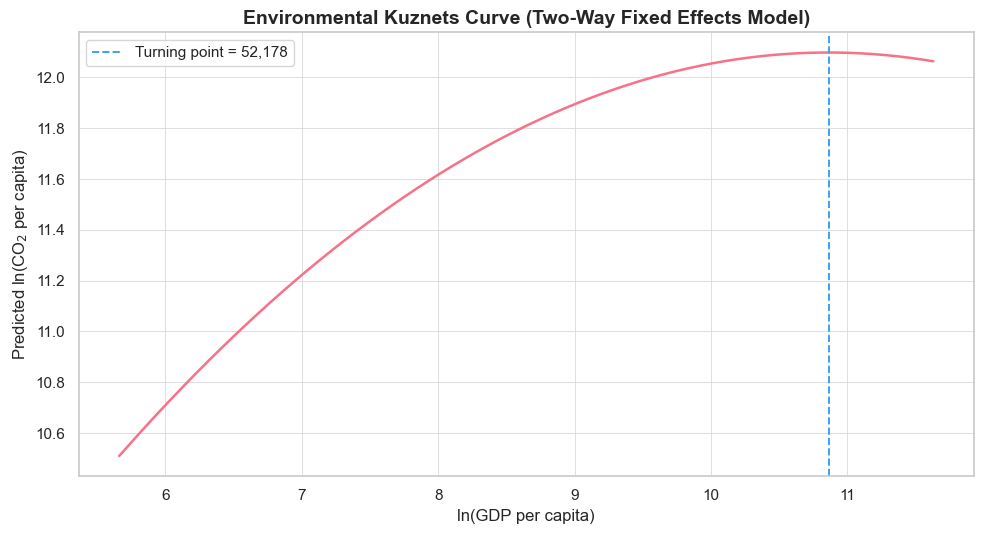

In [122]:
# 7.2 EKC Plot
sns.set_theme(style="whitegrid")
plt.rc('grid', color='0.85', linestyle='-', linewidth=0.6)
plt.rc('axes', titlesize=14, labelsize=12)
plt.rc('xtick', labelsize=11)
plt.rc('ytick', labelsize=11)

# Use a pleasant HUSL color palette for consistency
curve_color = sns.color_palette("husl", 1)[0]
tp_color = sns.color_palette("husl", 3)[2]

# 7.2.1 Range of lnGDP
lnGDP_min = panel_df["lnGDP"].min()
lnGDP_max = panel_df["lnGDP"].max()
lnGDP_range = np.linspace(lnGDP_min, lnGDP_max, 200)

# 7.2.2 Prediction dataframe
mean_vals = {
    "lnEnergy": panel_df["lnEnergy"].mean(),
    "lnUrban": panel_df["lnUrban"].mean(),
    "lnTrade": panel_df["lnTrade"].mean(),
    "renewable_pct": panel_df["renewable_pct"].mean(),
    "fossil_fuel_pct": panel_df["fossil_fuel_pct"].mean(),
    "lnPopDensity": panel_df["lnPopDensity"].mean(),
    "industry_value_added_pct_gdp": panel_df["industry_value_added_pct_gdp"].mean()
}

pred_df = pd.DataFrame({
    "lnGDP": lnGDP_range,
    "lnGDP_sq": lnGDP_range**2,
    **mean_vals
})

# 7.2.3 Predicted lnCO₂
beta = fe_tw_manual.params

pred_df["pred_lnCO2"] = (
    beta["lnGDP"] * pred_df["lnGDP"] +
    beta["lnGDP_sq"] * pred_df["lnGDP_sq"] +
    beta["lnEnergy"] * pred_df["lnEnergy"] +
    beta["lnUrban"] * pred_df["lnUrban"] +
    beta["lnTrade"] * pred_df["lnTrade"] +
    beta["renewable_pct"] * pred_df["renewable_pct"] +
    beta["fossil_fuel_pct"] * pred_df["fossil_fuel_pct"] +
    beta["lnPopDensity"] * pred_df["lnPopDensity"] +
    beta["industry_value_added_pct_gdp"] * pred_df["industry_value_added_pct_gdp"]
)

# 7.2.4 Plot
fig = plt.figure(figsize=(10, 5.5))
ax = fig.add_subplot(1, 1, 1)

ax.plot(
    lnGDP_range,
    pred_df["pred_lnCO2"],
    color=curve_color,
    linewidth=1.8
)

# Turning point line
ax.axvline(
    turning_log_gdp,
    color=tp_color,
    linestyle="--",
    linewidth=1.4,
    label=f"Turning point = {turning_gdp_pc:,.0f}"
)

ax.set_xlabel("ln(GDP per capita)")
ax.set_ylabel("Predicted ln(CO$_2$ per capita)")
ax.set_title("Environmental Kuznets Curve (Two-Way Fixed Effects Model)", weight="bold")

ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()

##### 7.3 Year Fixed Effects Plot

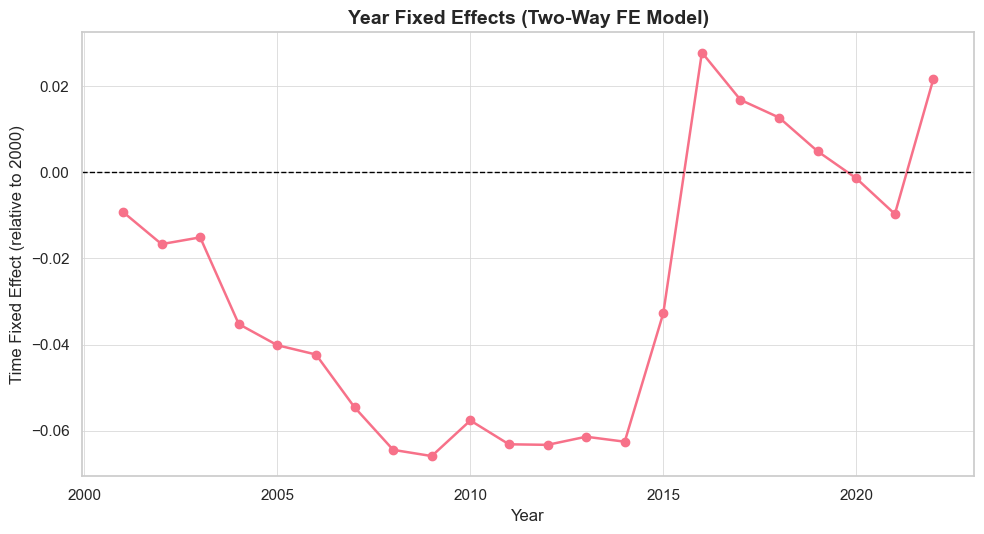

In [123]:
# Year Fixed Effects Plot (Final Correct Version)
sns.set_theme(style="whitegrid")
plt.rc('grid', color='0.85', linestyle='-', linewidth=0.6)
plt.rc('axes', titlesize=14, labelsize=12)
plt.rc('xtick', labelsize=11)
plt.rc('ytick', labelsize=11)

color_fe = sns.color_palette("husl", 1)[0]

# Extract Year FE correctly
year_coefs = fe_tw_manual.params.filter(regex=r"^d\d{4}$")
years = year_coefs.index.str.replace("d", "", regex=False).astype(int)

# Plot
fig = plt.figure(figsize=(10, 5.5))
ax = fig.add_subplot(1, 1, 1)

ax.plot(
    years,
    year_coefs.values,
    marker="o",
    linewidth=1.8,
    color=color_fe
)

# Baseline
ax.axhline(0, color="black", linestyle="--", linewidth=1)

# Labels + title
ax.set_title("Year Fixed Effects (Two-Way FE Model)", weight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("Time Fixed Effect (relative to 2000)")

ax.grid(True)
plt.tight_layout()
plt.show()

##### 7.4 Coefficient Plot (Two-Way FE Model)

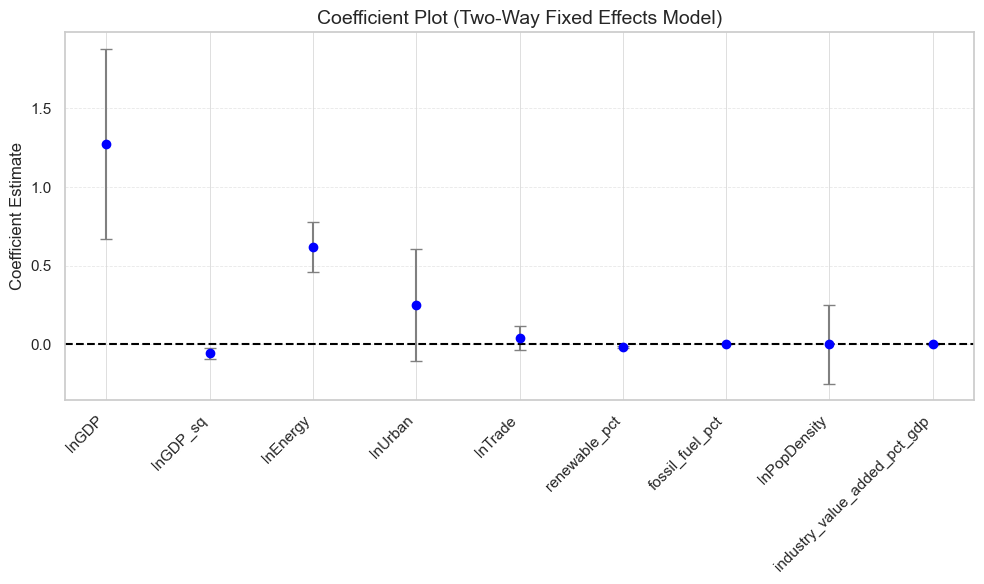

In [124]:
# Coefficient Plot (Two-Way FE Model)

# Extract only non-year coefficients
coef = fe_tw_manual.params.drop(labels=fe_tw_manual.params.filter(regex=r"^d\d{4}$").index)

# Standard errors
se = fe_tw_manual.std_errors[coef.index]

# 95% CI
ci_lower = coef - 1.96 * se
ci_upper = coef + 1.96 * se

# Plot
plt.figure(figsize=(10, 6))
plt.errorbar(
    coef.index,
    coef.values,
    yerr=[coef.values - ci_lower, ci_upper - coef.values],
    fmt='o',
    color='blue',
    ecolor='gray',
    capsize=4
)

plt.axhline(0, color='black', linestyle='--')
plt.xticks(rotation=45, ha='right')
plt.title("Coefficient Plot (Two-Way Fixed Effects Model)")
plt.ylabel("Coefficient Estimate")
plt.tight_layout()
plt.grid(True, axis='y', linestyle='--', alpha=0.6)

plt.show()


##### 7.5 Actual vs Fitted Plot (Two-Way FE Model)

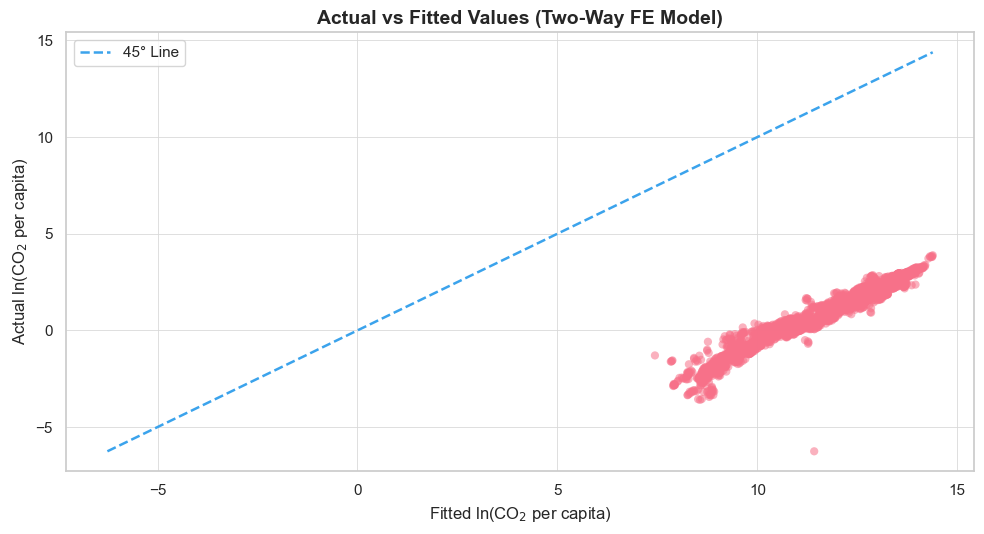

In [125]:
# Actual vs Fitted Plot
sns.set_theme(style="whitegrid")
plt.rc('grid', color='0.85', linestyle='-', linewidth=0.6)
plt.rc('axes', titlesize=14, labelsize=12)
plt.rc('xtick', labelsize=11)
plt.rc('ytick', labelsize=11)

scatter_color = sns.color_palette("husl", 1)[0]
line_color = sns.color_palette("husl", 3)[2]

# Actual and fitted
y = panel_df["lnCO2"]
fitted_vals = fe_tw_manual.fitted_values

y_min = float(y.min())
y_max = float(y.max())
f_min = fitted_vals.min().iloc[0]
f_max = fitted_vals.max().iloc[0]

min_val = min(y_min, f_min)
max_val = max(y_max, f_max)

# Plot
fig = plt.figure(figsize=(10, 5.5))
ax = fig.add_subplot(1, 1, 1)

# Scatter
ax.scatter(
    fitted_vals,
    y,
    alpha=0.55,
    s=35,
    color=scatter_color,
    edgecolor="none"
)

# 45-degree line
ax.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--",
    linewidth=1.8,
    color=line_color,
    label="45° Line"
)

# Labels (mathtext avoids Unicode CO₂ issue)
ax.set_xlabel(r"Fitted ln(CO$_2$ per capita)")
ax.set_ylabel(r"Actual ln(CO$_2$ per capita)")
ax.set_title("Actual vs Fitted Values (Two-Way FE Model)", weight="bold")

ax.grid(True)
ax.legend()
plt.tight_layout()
plt.show()

##### 7.6 Time Fixed Effects Plot

      time_effect  time_effect_norm
year                               
2000     -10.8219            0.0000
2001     -10.8235           -0.0017
2002     -10.8258           -0.0039
2003     -10.8249           -0.0030
2004     -10.7571            0.0648
2005     -10.7503            0.0716
2006     -10.7604            0.0615
2007     -10.7911            0.0308
2008     -10.8171            0.0048
2009     -10.8202            0.0017
2010     -10.8195            0.0024
2011     -10.8210            0.0009
2012     -10.8250           -0.0031
2013     -10.8235           -0.0016
2014     -10.8300           -0.0081


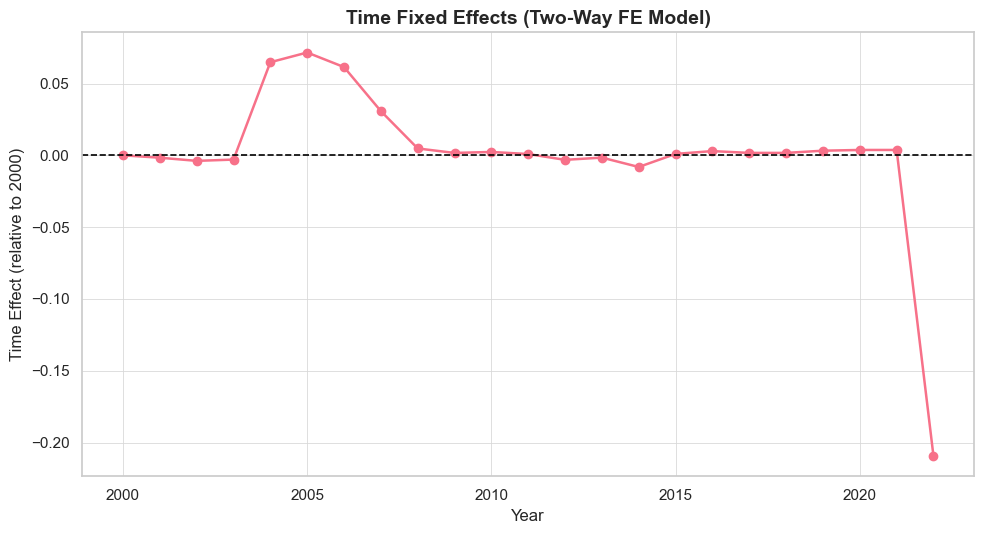

In [126]:
# Extract full FE series

sns.set_theme(style="whitegrid")
plt.rc('grid', color='0.85', linestyle='-', linewidth=0.6)
plt.rc('axes', titlesize=14, labelsize=12)
plt.rc('xtick', labelsize=11)
plt.rc('ytick', labelsize=11)

curve_color = sns.color_palette("husl", 1)[0]
baseline_color = "black"

effects = fe_tw_manual.estimated_effects["estimated_effects"]

# Convert to DataFrame structure
df_eff = effects.reset_index(name="effect")

# Group by year to isolate λₜ
time_fe = df_eff.groupby("year")["effect"].mean()

# Convert to DataFrame + normalize relative to 2000
time_fe = time_fe.to_frame().rename(columns={"effect": "time_effect"})
base = time_fe.loc[2000, "time_effect"]
time_fe["time_effect_norm"] = time_fe["time_effect"] - base

print(time_fe.head(15))

# Plot
fig = plt.figure(figsize=(10, 5.5))
ax = fig.add_subplot(1, 1, 1)

ax.plot(
    time_fe.index,
    time_fe["time_effect_norm"],
    marker="o",
    linewidth=1.8,
    color=curve_color
)

# Baseline at zero
ax.axhline(0, linestyle="--", color=baseline_color, linewidth=1.2)

# Labels + title
ax.set_title("Time Fixed Effects (Two-Way FE Model)", weight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("Time Effect (relative to 2000)")

ax.grid(True)
plt.tight_layout()
plt.show()

##### 7.7 First-order Autocorrelation in Idiosyncratic Errors

In [127]:
# Get residuals from the FE model
resid = fe_tw_manual.resids  # MultiIndex: (country_name, year)

# Convert to DataFrame
df_r = resid.reset_index()
df_r = df_r.rename(columns={0: "resid", "residual": "resid"})

# Sort for safety
df_r = df_r.sort_values(["country_name", "year"])

# Create lagged residuals by country
df_r["resid_lag"] = df_r.groupby("country_name")["resid"].shift(1)

# Drop rows without a lag
df_r2 = df_r.dropna(subset=["resid", "resid_lag"])

# Compute AR(1) correlation across all countries
rho1 = df_r2["resid"].corr(df_r2["resid_lag"])

print(f"First-order serial correlation ⍴1: {rho1:.4f}")

First-order serial correlation ⍴1: 0.8306


In [128]:
# Wooldridge Test for Serial Correlation
df = panel_df.copy()

y = df["lnCO2"]
X = df[[
    "lnGDP", "lnGDP_sq", "lnEnergy", "lnUrban",
    "lnTrade", "renewable_pct", "fossil_fuel_pct",
    "lnPopDensity", "industry_value_added_pct_gdp"
]]

X = sm.add_constant(X)

# Fit FE model to get residuals
fe_test = PanelOLS(y, X, entity_effects=True).fit()
resid = fe_test.resids

# Create lagged residuals
df_resid = resid.reset_index()
df_resid["lag_resid"] = df_resid.groupby("country_name")["residual"].shift(1)

# Drop missing lags
df_resid = df_resid.dropna()

# Regress residual on lagged residual
y_r = df_resid["residual"]
X_r = sm.add_constant(df_resid["lag_resid"])

wooldridge_reg = sm.OLS(y_r, X_r).fit()

# F statistic and p-value
f_stat = wooldridge_reg.fvalue
p_val = wooldridge_reg.f_pvalue

print("Wooldridge Test for Serial Correlation")
print("--------------------------------------")
print(f"F-statistic: {f_stat:.4f}")
print(f"p-value:     {p_val:.4f}")

if p_val < 0.05:
    print("Reject H0: Serial correlation detected (expected in panels).")
else:
    print("Fail to reject H0: No serial correlation.")

Wooldridge Test for Serial Correlation
--------------------------------------
F-statistic: 6508.3847
p-value:     0.0000
Reject H0: Serial correlation detected (expected in panels).
